In [ ]:
# CELL 1 — Install dependencies
!pip install yfinance xgboost shap wbdata tensorflow scikit-learn joblib --quiet
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
✅ Dependencies installed


In [ ]:
# CELL 2 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, precision_score, recall_score, f1_score)
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout,
                                     RepeatVector, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

print('✅ All imports successful')
print('TensorFlow:', tf.__version__)

✅ All imports successful
TensorFlow: 2.20.0


In [ ]:
# CELL 3 — Create folder structure
for folder in ['data', 'data/stock_prices', 'models']:
    os.makedirs(folder, exist_ok=True)
print('✅ Folders ready')

✅ Folders ready


In [ ]:
# CELL 4 — Load Kaggle Financial Ratios
# ⚠️  Upload kaggle_financials.csv to the data/ folder first!
# In Colab: Files panel (left sidebar) → upload → move to data/

fin_df = pd.read_csv('data/kaggle_financials.csv')

FINANCIAL_COLS = [f'X{i}' for i in range(1, 19)]

# Clean: fill missing with median, clip outliers
for col in FINANCIAL_COLS:
    fin_df[col] = fin_df[col].astype(str)
    fin_df[col] = fin_df[col].str.replace('[', '', regex=False)
    fin_df[col] = fin_df[col].str.replace(']', '', regex=False)

    fin_df[col] = pd.to_numeric(fin_df[col], errors='coerce')

    fin_df[col] = fin_df[col].fillna(fin_df[col].median())
    fin_df[col] = fin_df[col].clip(
        fin_df[col].quantile(0.01),
        fin_df[col].quantile(0.99)
    )

fin_df['bankrupt'] = (fin_df['status_label'] == 'failed').astype(int)
fin_df['year']     = fin_df['year'].astype(int)

print('Dataset shape:', fin_df.shape)
print('Columns:', fin_df.columns.tolist())
print(f'Bankruptcy rate: {fin_df["bankrupt"].mean():.2%}')
fin_df.head()

Dataset shape: (78682, 22)
Columns: ['company_name', 'status_label', 'year', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'bankrupt']
Bankruptcy rate: 6.63%


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,X15,X16,X17,X18,bankrupt
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302,0
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888,0
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514,0
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592,0
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467,0


In [ ]:
# CELL 5 — Macroeconomic Features (World Bank API)
try:
    import wbdata
    indicators = {
        'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
        'FP.CPI.TOTL.ZG':    'inflation',
        'SL.UEM.TOTL.ZS':    'unemployment'
    }
    macro_raw = wbdata.get_dataframe(indicators, country='US').reset_index()
    macro_raw.columns = ['date', 'gdp_growth', 'inflation', 'unemployment']
    macro_raw['year'] = macro_raw['date'].astype(str).str[:4].astype(int)
    macro_df = macro_raw[['year','gdp_growth','inflation','unemployment']].dropna()
    macro_df = macro_df.sort_values('year').ffill().bfill().reset_index(drop=True)
    print('✅ World Bank macro data loaded')
except Exception as e:
    print(f'World Bank API failed ({e}). Using fallback data.')
    years = list(range(1999, 2027))
    macro_df = pd.DataFrame({
        'year':         years,
        'gdp_growth':   [4.1,1.0,1.8,2.8,3.9,3.5,2.9,1.9,-0.1,-2.5,
                         2.6,1.6,2.2,1.8,2.5,2.9,2.3,2.9,2.3,-3.4,
                         5.7,2.1,2.5,2.2,2.8,2.5,2.5][:len(years)],
        'inflation':    [3.4,2.8,1.6,2.3,2.7,3.4,3.2,2.9,3.8,-0.3,
                         1.6,3.2,2.1,1.5,1.6,0.1,1.3,2.1,1.8,1.2,
                         4.7,8.0,4.1,3.4,2.5,2.2,2.0][:len(years)],
        'unemployment': [4.0,4.7,5.8,6.0,5.5,5.1,4.6,4.6,5.8,9.3,
                         9.6,8.9,8.1,7.4,6.2,5.3,4.9,4.4,3.9,8.1,
                         5.4,3.6,3.5,3.7,4.0,4.0,4.0][:len(years)]
    })
    print('✅ Fallback macro data created')

MACRO_COLS = ['gdp_growth', 'inflation', 'unemployment']
macro_df.to_csv('data/macro_features.csv', index=False)
print(macro_df.tail())

✅ World Bank macro data loaded
    year  gdp_growth  inflation  unemployment
29  2020   -2.163029   1.233584         8.055
30  2021    6.055053   4.697859         5.349
31  2022    2.512375   8.002800         3.650
32  2023    2.887556   4.116338         3.638
33  2024    2.793001   2.949525         4.022


In [ ]:
# CELL 6 — Download S&P 500 + Engineer 10 Time-Series Features
sp500_raw = yf.download('^GSPC', start='1999-01-01', auto_adjust=True, progress=False)
sp500_raw = sp500_raw.reset_index()

# Fix multi-level columns (yfinance quirk)
if isinstance(sp500_raw.columns, pd.MultiIndex):
    sp500_raw.columns = [col[0] if col[1] == '' else col[0] for col in sp500_raw.columns]

sp500_raw = sp500_raw[sp500_raw['Date'].astype(str).str.match(r'\d{4}')]
sp500_raw['Date']   = pd.to_datetime(sp500_raw['Date'])
sp500_raw['Close']  = pd.to_numeric(sp500_raw['Close'],  errors='coerce')
sp500_raw['Volume'] = pd.to_numeric(sp500_raw['Volume'], errors='coerce')
sp500_raw = sp500_raw.dropna(subset=['Close']).sort_values('Date').reset_index(drop=True)

close = sp500_raw['Close']
sp500_raw['return_1d']     = close.pct_change()
sp500_raw['ma_10']         = close.rolling(10).mean()
sp500_raw['ma_20']         = close.rolling(20).mean()
sp500_raw['ma_50']         = close.rolling(50).mean()
sp500_raw['volatility_20'] = sp500_raw['return_1d'].rolling(20).std()

delta = close.diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
sp500_raw['rsi_14'] = 100 - (100 / (1 + gain / (loss + 1e-8)))

ema12 = close.ewm(span=12).mean()
ema26 = close.ewm(span=26).mean()
sp500_raw['macd'] = ema12 - ema26

bb_std = close.rolling(20).std()
sp500_raw['bb_upper_dist'] = (close.rolling(20).mean() + 2*bb_std - close) / (close + 1e-8)
sp500_raw['bb_lower_dist'] = (close - (close.rolling(20).mean() - 2*bb_std)) / (close + 1e-8)
sp500_raw['volume_change'] = sp500_raw['Volume'].pct_change()

LSTM_FEATURES = ['return_1d','ma_10','ma_20','ma_50','volatility_20',
                 'rsi_14','macd','bb_upper_dist','bb_lower_dist','volume_change']

sp500_feat = sp500_raw[['Date'] + LSTM_FEATURES].dropna().reset_index(drop=True)
sp500_feat['year'] = sp500_feat['Date'].dt.year
print('✅ S&P 500 features engineered:', sp500_feat.shape)

✅ S&P 500 features engineered: (6826, 12)


In [ ]:
# CELL 7 — Build 90-Day LSTM Sliding Windows
TIME_STEPS = 90
N_FEATURES = len(LSTM_FEATURES)
EMB_DIM    = 32

# Clean the data before scaling
sp500_feat[LSTM_FEATURES] = sp500_feat[LSTM_FEATURES].replace([np.inf, -np.inf], np.nan)

# Fill missing values
sp500_feat[LSTM_FEATURES] = sp500_feat[LSTM_FEATURES].fillna(method='ffill').fillna(method='bfill')

scaler_lstm  = MinMaxScaler()
sp500_scaled = scaler_lstm.fit_transform(sp500_feat[LSTM_FEATURES])

X_lstm_all = []
dates_lstm = []
for i in range(len(sp500_scaled) - TIME_STEPS):
    X_lstm_all.append(sp500_scaled[i : i + TIME_STEPS])
    dates_lstm.append(sp500_feat['Date'].iloc[i + TIME_STEPS])

X_lstm_all = np.array(X_lstm_all)
years_lstm = pd.Series(pd.to_datetime(dates_lstm)).dt.year.values

np.save('data/X_sp500_lstm.npy', X_lstm_all)
np.save('data/years_lstm.npy',   years_lstm)
print('LSTM sequences shape:', X_lstm_all.shape)

LSTM sequences shape: (6736, 90, 10)


In [ ]:
# CELL 8 — Build LSTM Autoencoder
# Regularization: Dropout + L2 + BatchNorm  (paper requirement)
L2_REG  = 0.001
DROPOUT = 0.3

inputs = Input(shape=(TIME_STEPS, N_FEATURES), name='market_input')

# Encoder
x = LSTM(64, return_sequences=True,
         kernel_regularizer=l2(L2_REG),
         recurrent_regularizer=l2(L2_REG),
         name='lstm_enc_1')(inputs)
x = Dropout(DROPOUT, name='dropout_enc_1')(x)
x = LSTM(32, return_sequences=False,
         kernel_regularizer=l2(L2_REG),
         name='lstm_enc_2')(x)
x = BatchNormalization(name='bn_enc')(x)
embedding = Dense(EMB_DIM, activation='relu',
                  kernel_regularizer=l2(L2_REG),
                  name='market_embedding')(x)

# Decoder
x = RepeatVector(TIME_STEPS, name='repeat')(embedding)
x = LSTM(32, return_sequences=True,
         kernel_regularizer=l2(L2_REG), name='lstm_dec_1')(x)
x = Dropout(DROPOUT, name='dropout_dec')(x)
x = LSTM(64, return_sequences=True,
         kernel_regularizer=l2(L2_REG), name='lstm_dec_2')(x)
outputs = Dense(N_FEATURES, name='reconstruction')(x)

autoencoder  = Model(inputs, outputs,   name='autoencoder')
lstm_encoder = Model(inputs, embedding, name='lstm_encoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ market_input (InputLayer)       │ (None, 90, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_1 (LSTM)               │ (None, 90, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_enc_1 (Dropout)         │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_2 (LSTM)               │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc (BatchNormalization)     │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ market_embedding (Dense)        │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_1 (LSTM)               │ (None, 90, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dec (Dropout)           │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_2 (LSTM)               │ (None, 90, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 90, 10)         │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,602 (260.16 KB)

 Trainable params: 66,538 (259.91 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2708

95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 0.1925 - val_loss: 0.1868 - learning_rate: 0.0010
Epoch 2/50
93/95 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0723

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0571 - val_loss: 0.1071 - learning_rate: 0.0010
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0291

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0250 - val_loss: 0.0707 - learning_rate: 0.0010
Epoch 4/50
93/95 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0164

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0149 - val_loss: 0.0552 - learning_rate: 0.0010
Epoch 5/50
93/95 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0114

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0108 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0091 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 7/50
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0083

95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0080 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 8/50
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0076

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0075 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 9/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0073 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 10/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0071 - val_loss: 0.0185 - learning_rate: 0.0010
Epoch 11/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0069
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0070 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 12/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0068 - val_loss: 0.0149 - learning_rate: 5.0000e-04
Epoch 13/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0067 - val_loss: 0.0169 - learning_rate: 5.0000e-04
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


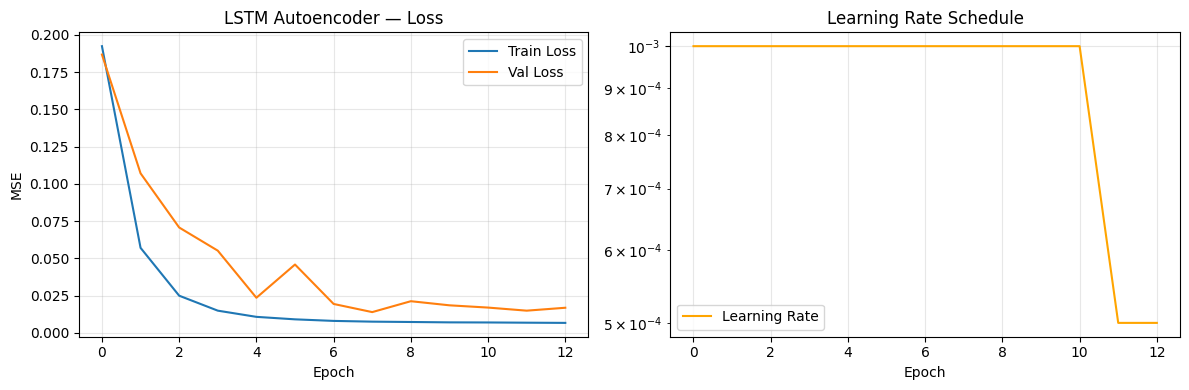

✅ LSTM trained — stopped at epoch 13


In [ ]:
# CELL 9 — Train LSTM with Early Stopping + LR Scheduling  (paper requirement)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)
checkpoint = ModelCheckpoint(
    'models/lstm_best_checkpoint.h5',
    monitor='val_loss', save_best_only=True, verbose=0
)

history = autoencoder.fit(
    X_lstm_all, X_lstm_all,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler, checkpoint],
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('LSTM Autoencoder — Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE')
ax1.legend(); ax1.grid(alpha=0.3)
lr_key = 'learning_rate' if 'learning_rate' in history.history else 'lr'
ax2.plot(history.history[lr_key], color='orange', label='Learning Rate')
ax2.set_title('Learning Rate Schedule')
ax2.set_xlabel('Epoch'); ax2.set_yscale('log')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/lstm_training_curves.png', dpi=150)
plt.show()
print(f'✅ LSTM trained — stopped at epoch {len(history.history["loss"])}')

In [ ]:
# CELL 10 — Extract Yearly Market Embeddings (32-dim per year)
LSTM_COLS = [f'lstm_emb_{i}' for i in range(EMB_DIM)]

all_embeddings = lstm_encoder.predict(X_lstm_all, verbose=1)
print('Raw embeddings shape:', all_embeddings.shape)

emb_df         = pd.DataFrame(all_embeddings, columns=LSTM_COLS)
emb_df['year'] = years_lstm
yearly_emb     = emb_df.groupby('year').mean().reset_index()

yearly_emb.to_csv('data/yearly_market_embeddings.csv', index=False)
lstm_encoder.save('models/lstm_market_encoder.keras')
print('✅ Yearly embeddings shape:', yearly_emb.shape)
print('Years covered:', yearly_emb['year'].tolist())

211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Raw embeddings shape: (6736, 32)
✅ Yearly embeddings shape: (28, 33)
Years covered: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [ ]:
# CELL 11 — Merge All Features: Financial + Macro + LSTM Embeddings
df = fin_df.copy()
df = df.merge(macro_df,   on='year', how='left')
df = df.merge(yearly_emb, on='year', how='left')

df[MACRO_COLS] = df[MACRO_COLS].fillna(df[MACRO_COLS].mean())
df[LSTM_COLS]  = df[LSTM_COLS].fillna(0)

ALL_FEATURES = FINANCIAL_COLS + MACRO_COLS + LSTM_COLS

print('Master dataframe shape:', df.shape)
print(f'Total features: {len(ALL_FEATURES)}')
print(f'  Financial ratios : {len(FINANCIAL_COLS)}')
print(f'  Macro features   : {len(MACRO_COLS)}')
print(f'  LSTM embeddings  : {len(LSTM_COLS)}')
df.to_csv('data/final_master.csv', index=False)
print('✅ Master dataframe saved')

Master dataframe shape: (78682, 57)
Total features: 53
  Financial ratios : 18
  Macro features   : 3
  LSTM embeddings  : 32
✅ Master dataframe saved


In [ ]:
# CELL 12 — Train/Val/Test Split + Feature Scaling
X = df[ALL_FEATURES]
y = df['bankrupt']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Bankruptcy rate — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}')

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


# Save scaler ONLY (not XGBoost here)
joblib.dump(scaler, 'models/scaler.pkl')

print('✅ Data split complete')
print('✅ Scaler saved')

Train: 47209 | Val: 15736 | Test: 15737
Bankruptcy rate — Train: 6.63% | Val: 6.63% | Test: 6.63%
✅ Data split complete
✅ Scaler saved


In [ ]:
# CELL 13 — Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_sc, y_train)

y_prob_rf_val = rf_model.predict_proba(X_val_sc)[:, 1]
print('==== Random Forest — Validation ====')
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_rf_val):.4f}')
print(classification_report(y_val, (y_prob_rf_val >= 0.5).astype(int)))

joblib.dump(rf_model, 'models/rf_model.pkl')
print('✅ Random Forest saved')

==== Random Forest — Validation ====
ROC-AUC: 0.7999
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     14692
           1       0.31      0.22      0.26      1044

    accuracy                           0.92     15736
   macro avg       0.63      0.59      0.61     15736
weighted avg       0.90      0.92      0.91     15736

✅ Random Forest saved


In [ ]:
# CELL 14 — Train XGBoost (SHAP-safe version)

import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=100
)
# ✅ Validation predictions (REQUIRED for stacking)
y_prob_rf_val  = rf_model.predict_proba(X_val_sc)[:, 1]
y_prob_xgb_val = xgb_model.predict_proba(X_val_sc)[:, 1]

print("✅ Validation predictions ready for stacking")

# ----------------------------
# SHAP FIX (IMPORTANT)
# ----------------------------
try:
    booster = xgb_model.get_booster()
    booster.set_param({'base_score': 0.5})
    print("✅ base_score fixed")
except Exception as e:
    print("⚠️ base_score fix skipped:", e)

# ----------------------------
# SAVE MODEL
# ----------------------------
joblib.dump(xgb_model, 'models/xgb_model.pkl')
print('✅ XGBoost saved (SHAP-safe)')

# ----------------------------
# CREATE SHAP EXPLAINER
# ----------------------------
try:
    shap_explainer = shap.TreeExplainer(xgb_model)
    print("✅ SHAP explainer initialized")
except Exception as e:
    print("⚠️ SHAP disabled:", e)
    shap_explainer = None

[0]	validation_0-logloss:0.68381
[100]	validation_0-logloss:0.48320
[200]	validation_0-logloss:0.42383
[300]	validation_0-logloss:0.37819
[400]	validation_0-logloss:0.34439
[500]	validation_0-logloss:0.31744
[599]	validation_0-logloss:0.29559
✅ Validation predictions ready for stacking
✅ base_score fixed
✅ XGBoost saved (SHAP-safe)
✅ SHAP explainer initialized


In [ ]:
# CELL 15 — Build Stacking Meta-Learner
# Input = [RF_prob, XGB_prob, 32-dim LSTM embedding]
# Trained on VALIDATION predictions (no leakage)

def get_lstm_emb_for_split(index_series):
    years = df.loc[index_series.index, 'year'].values
    emb_lookup = yearly_emb.set_index('year')[LSTM_COLS]

    result = []
    for yr in years:
        if yr in emb_lookup.index:
            result.append(emb_lookup.loc[yr].values.astype(float))
        else:
            result.append(np.zeros(EMB_DIM))
    return np.array(result)


lstm_emb_val  = get_lstm_emb_for_split(y_val)
lstm_emb_test = get_lstm_emb_for_split(y_test)

lstm_emb_val  = np.nan_to_num(lstm_emb_val, nan=0.0)
lstm_emb_test = np.nan_to_num(lstm_emb_test, nan=0.0)

X_meta_train = np.column_stack([
    y_prob_rf_val,
    y_prob_xgb_val,
    lstm_emb_val
])

y_meta_train = y_val.values

y_prob_rf_test  = rf_model.predict_proba(X_test_sc)[:, 1]
y_prob_xgb_test = xgb_model.predict_proba(X_test_sc)[:, 1]

X_meta_test = np.column_stack([
    y_prob_rf_test,
    y_prob_xgb_test,
    lstm_emb_test
])

y_meta_test = y_test.values

meta_model = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
    random_state=42
)

meta_model.fit(X_meta_train, y_meta_train)

joblib.dump(meta_model, 'models/meta_model.pkl')

print('✅ Meta-learner saved')
print(f'Meta-learner input: {X_meta_train.shape[1]} features')
print(f'  (2 base model probs + {EMB_DIM} LSTM embedding dims)')

✅ Meta-learner saved
Meta-learner input: 34 features
  (2 base model probs + 32 LSTM embedding dims)


In [ ]:
# CELL 16 — Final Evaluation on Holdout Test Set
y_meta_prob = meta_model.predict_proba(X_meta_test)[:, 1]
y_meta_pred = meta_model.predict(X_meta_test)

print('=' * 55)
print('FINAL RESULTS — HOLDOUT TEST SET')
print('=' * 55)

for name, prob, label in [
    ('Random Forest',  y_prob_rf_test,  (y_prob_rf_test  >= 0.5).astype(int)),
    ('XGBoost',        y_prob_xgb_test, (y_prob_xgb_test >= 0.5).astype(int)),
    ('Stacked Model',  y_meta_prob,     y_meta_pred),
]:
    print(f'\n--- {name} ---')
    print(f'ROC-AUC : {roc_auc_score(y_meta_test, prob):.4f}')
    print(classification_report(y_meta_test, label))

FINAL RESULTS — HOLDOUT TEST SET

--- Random Forest ---
ROC-AUC : 0.8077
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     14693
           1       0.33      0.25      0.28      1044

    accuracy                           0.92     15737
   macro avg       0.64      0.61      0.62     15737
weighted avg       0.91      0.92      0.91     15737


--- XGBoost ---
ROC-AUC : 0.8428
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     14693
           1       0.29      0.52      0.37      1044

    accuracy                           0.88     15737
   macro avg       0.63      0.71      0.65     15737
weighted avg       0.92      0.88      0.90     15737


--- Stacked Model ---
ROC-AUC : 0.8389
              precision    recall  f1-score   support

           0       0.98      0.77      0.86     14693
           1       0.19      0.74      0.30      1044

    accuracy                       

In [ ]:
# CELL 17 — Threshold Tuning
print('Threshold sensitivity:')
print(f'{"Thresh":>8} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-'*38)

best_f1, best_thresh = 0, 0.5
for t in np.arange(0.1, 0.9, 0.05):
    preds = (y_meta_prob >= t).astype(int)
    if preds.sum() == 0: continue
    p  = precision_score(y_meta_test, preds, zero_division=0)
    r  = recall_score(y_meta_test,    preds, zero_division=0)
    f1 = f1_score(y_meta_test,        preds, zero_division=0)
    marker = ' ←' if f1 > best_f1 else ''
    print(f'{t:>8.2f} {p:>10.3f} {r:>8.3f} {f1:>8.3f}{marker}')
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f'\n✅ Best threshold: {best_thresh:.2f}  (F1 = {best_f1:.3f})')

Threshold sensitivity:
  Thresh  Precision   Recall       F1
--------------------------------------
    0.10      0.069    0.999    0.129 ←
    0.15      0.080    0.989    0.148 ←
    0.20      0.098    0.968    0.179 ←
    0.25      0.113    0.929    0.201 ←
    0.30      0.128    0.898    0.225 ←
    0.35      0.142    0.869    0.245 ←
    0.40      0.155    0.820    0.261 ←
    0.45      0.169    0.781    0.278 ←
    0.50      0.187    0.741    0.299 ←
    0.55      0.203    0.698    0.314 ←
    0.60      0.219    0.648    0.328 ←
    0.65      0.240    0.602    0.344 ←
    0.70      0.265    0.553    0.358 ←
    0.75      0.298    0.489    0.370 ←
    0.80      0.338    0.409    0.370
    0.85      0.411    0.330    0.366

✅ Best threshold: 0.75  (F1 = 0.370)


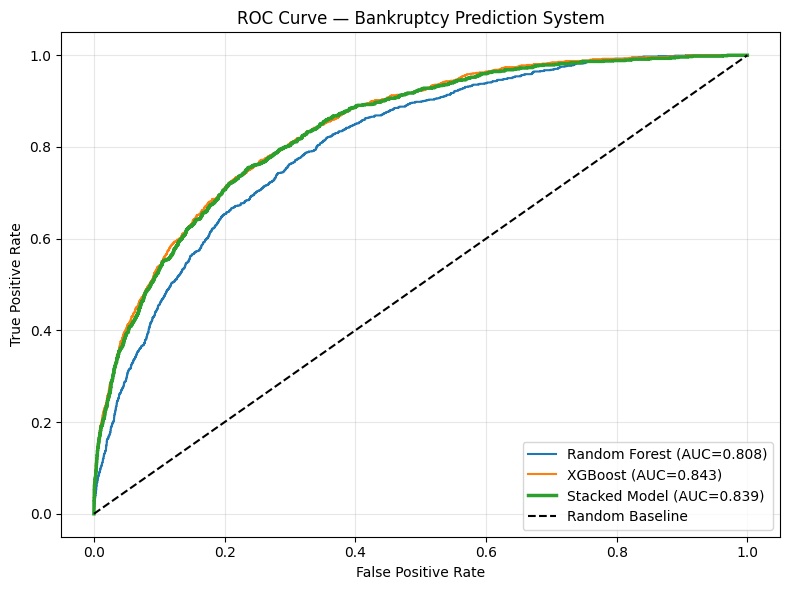

In [ ]:
# CELL 18 — ROC Curve Comparison
plt.figure(figsize=(8, 6))
for name, probs in [('Random Forest', y_prob_rf_test),
                    ('XGBoost',       y_prob_xgb_test),
                    ('Stacked Model', y_meta_prob)]:
    fpr, tpr, _ = roc_curve(y_meta_test, probs)
    auc = roc_auc_score(y_meta_test, probs)
    lw  = 2.5 if name == 'Stacked Model' else 1.5
    plt.plot(fpr, tpr, linewidth=lw, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Bankruptcy Prediction System')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/roc_curve.png', dpi=150)
plt.show()

Running SHAP analysis...


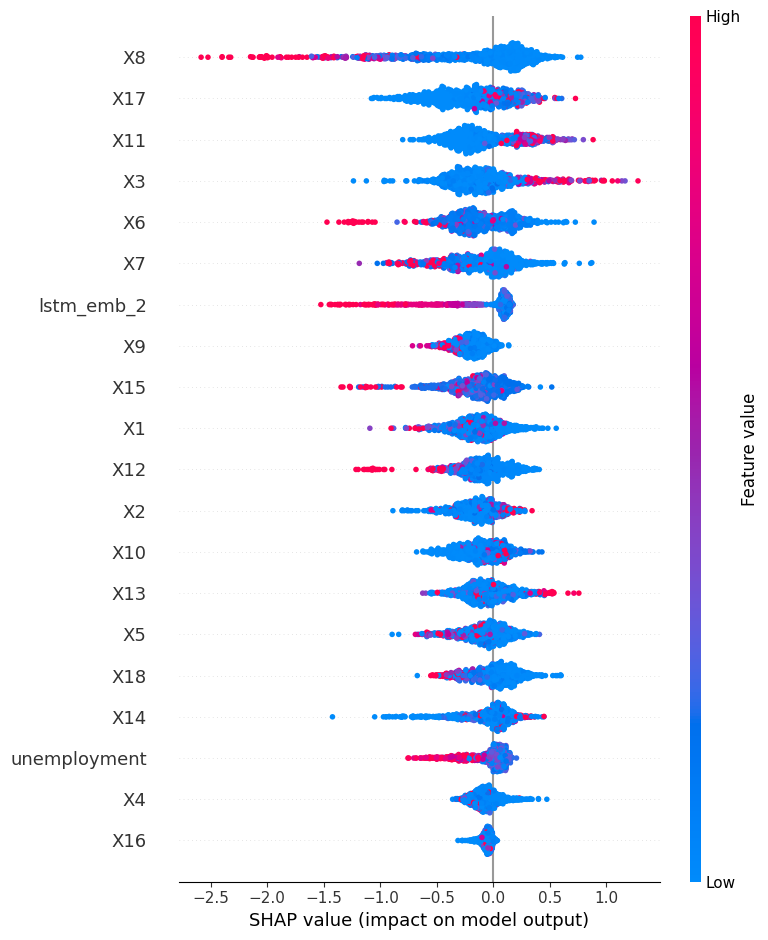

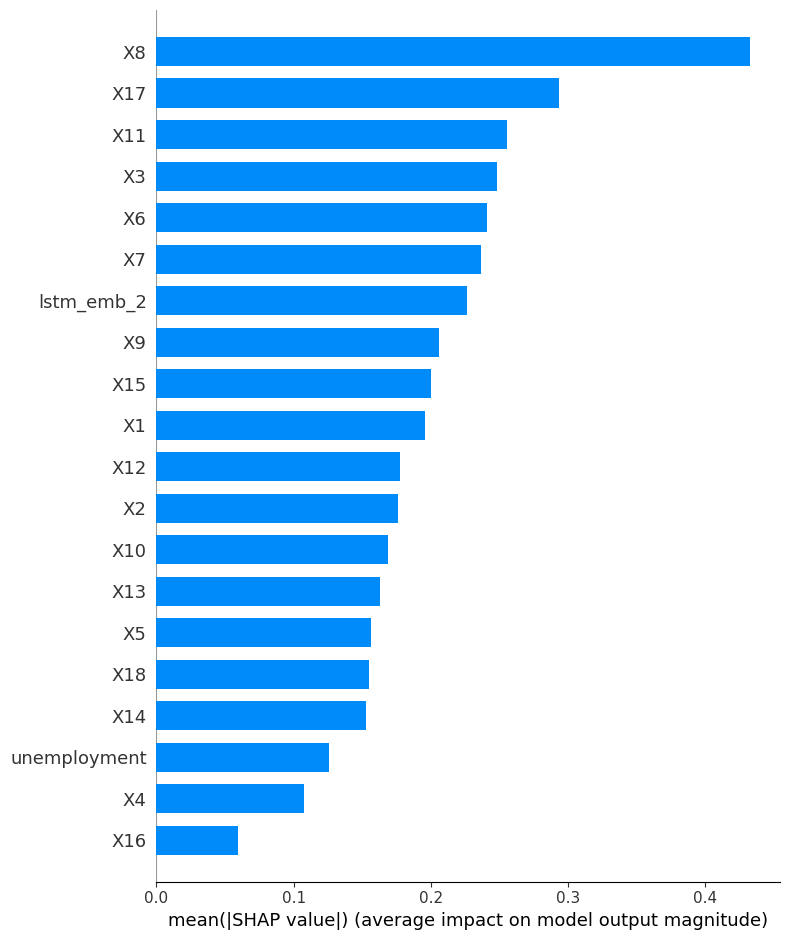

In [ ]:
print('Running SHAP analysis...')

SHAP_SAMPLE = min(1000, len(X_test_sc))

import joblib
import shap

# ✅ load correct saved model
xgb_model = joblib.load('models/xgb_model.pkl')

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sc[:SHAP_SAMPLE])

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_sc[:SHAP_SAMPLE],
    feature_names=ALL_FEATURES,
    max_display=20,
    show=True
)

# Bar plot
shap.summary_plot(
    shap_values,
    X_test_sc[:SHAP_SAMPLE],
    feature_names=ALL_FEATURES,
    plot_type='bar',
    max_display=20,
    show=True
)

FEATURE GROUP CONTRIBUTION (SHAP)
Financial Ratios (X1-X18) : 80.1%
Macro Features            : 4.2%
LSTM Market Embeddings    : 15.7%


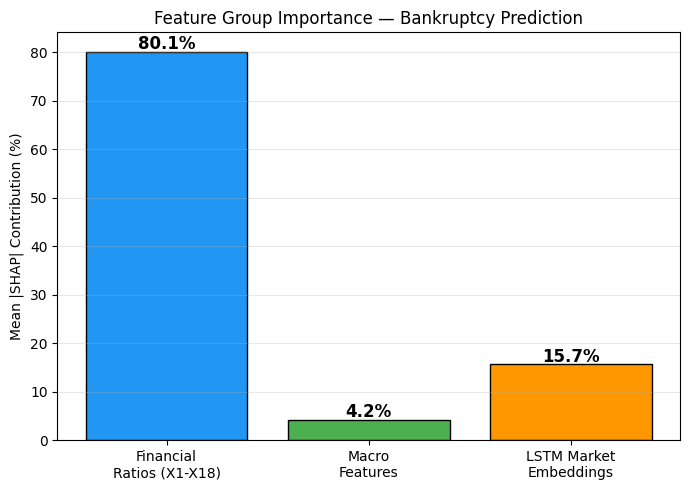

✅ SHAP analysis complete


In [ ]:
# CELL 20 — Feature Group Contribution
shap_df   = pd.DataFrame(shap_values, columns=ALL_FEATURES)
fin_shap  = shap_df[FINANCIAL_COLS].abs().mean().sum()
mac_shap  = shap_df[MACRO_COLS].abs().mean().sum()
lstm_shap = shap_df[LSTM_COLS].abs().mean().sum()
total     = fin_shap + mac_shap + lstm_shap

print('='*45)
print('FEATURE GROUP CONTRIBUTION (SHAP)')
print('='*45)
print(f'Financial Ratios (X1-X18) : {fin_shap/total:.1%}')
print(f'Macro Features            : {mac_shap/total:.1%}')
print(f'LSTM Market Embeddings    : {lstm_shap/total:.1%}')
print('='*45)

groups   = ['Financial\nRatios (X1-X18)', 'Macro\nFeatures', 'LSTM Market\nEmbeddings']
contribs = [fin_shap/total, mac_shap/total, lstm_shap/total]
colors   = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(7,5))
bars = plt.bar(groups, [c*100 for c in contribs], color=colors, edgecolor='black')
for bar, val in zip(bars, contribs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
plt.ylabel('Mean |SHAP| Contribution (%)')
plt.title('Feature Group Importance — Bankruptcy Prediction')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('models/shap_group_importance.png', dpi=150)
plt.show()
print('✅ SHAP analysis complete')

In [ ]:
# CELL 21 — Feature Descriptions + Helper Functions

FEATURE_DESCRIPTIONS = {
    'X1':  'Working Capital / Total Assets',
    'X2':  'Retained Earnings / Total Assets',
    'X3':  'EBIT / Total Assets',
    'X4':  'Market Value of Equity / Total Liabilities',
    'X5':  'Revenue / Total Assets',
    'X6':  'Net Income',
    'X7':  'Total Liabilities / Total Assets (Debt Ratio)',
    'X8':  'Current Assets / Current Liabilities (Current Ratio)',
    'X9':  'Total Assets',
    'X10': 'Revenue Growth Rate',
    'X11': 'Operating Cash Flow',
    'X12': 'Return on Assets (ROA)',
    'X13': 'Return on Equity (ROE)',
    'X14': 'Interest Coverage Ratio',
    'X15': 'Book Value per Share',
    'X16': 'Cash & Short-term Investments',
    'X17': 'Long-term Debt',
    'X18': 'Gross Profit Margin',
    'gdp_growth':   'GDP Growth Rate (%)',
    'inflation':    'Inflation Rate (%)',
    'unemployment': 'Unemployment Rate (%)',
}

# Load percentiles from training data for context
train_df  = pd.read_csv('data/final_master.csv')
train_pct = {}
for col in FINANCIAL_COLS + MACRO_COLS:
    train_pct[col] = sorted(train_df[col].dropna().values)


def risk_label(prob):
    if prob < 0.08:
        return '🟢 LOW RISK', 'The company appears financially healthy.'
    elif prob < 0.18:
        return '🟡 MODERATE RISK', 'Some financial weaknesses detected.'
    elif prob < 0.30:
        return '🟠 HIGH RISK', 'Significant financial stress indicators present.'
    elif prob < 0.50:
        return '🔴 VERY HIGH RISK', 'Strong bankruptcy warning signals detected.'
    else:
        return '💀 CRITICAL RISK', 'Extreme bankruptcy risk.'
def get_percentile(feat, val):
    arr = train_pct.get(feat, [])
    if len(arr) == 0: return 50
    return int(np.searchsorted(arr, val) / len(arr) * 100)

def get_plain_english(feature, shap_val, feature_value, percentile):
    desc     = FEATURE_DESCRIPTIONS.get(feature, feature)
    impact   = abs(shap_val)
    severity = 'strongly' if impact > 0.15 else 'moderately' if impact > 0.07 else 'slightly'
    effect   = 'INCREASES bankruptcy risk' if shap_val > 0 else 'REDUCES bankruptcy risk'
    arrow    = '⚠️' if shap_val > 0 else '✅'
    if percentile <= 20:   context = 'very low (bottom 20% of companies)'
    elif percentile <= 40: context = 'below average (bottom 40%)'
    elif percentile <= 60: context = 'around average'
    elif percentile <= 80: context = 'above average (top 40%)'
    else:                  context = 'very high (top 20%)'
    return (f'{arrow}  {desc}\n'
            f'    Value: {feature_value:.3f} — {context}\n'
            f'    This {severity} {effect}')

print('✅ Helper functions ready')

✅ Helper functions ready


In [ ]:
# CELL 22 — Core Prediction Function (SHAP-safe)

def predict_company_health(financial_ratios, year, company_name='Company'):

    # Step 1: Macro features
    macro_row = macro_df[macro_df['year'] == year]
    if macro_row.empty:
        macro_row = macro_df.sort_values('year').iloc[[-1]]

    macro_vals = {
        'gdp_growth':   float(macro_row['gdp_growth'].values[0]),
        'inflation':    float(macro_row['inflation'].values[0]),
        'unemployment': float(macro_row['unemployment'].values[0]),
    }

    # Step 2: LSTM embedding
    emb_row = yearly_emb[yearly_emb['year'] == year]
    if emb_row.empty:
        emb_row = yearly_emb.sort_values('year').iloc[[-1]]

    lstm_vals = {
        f'lstm_emb_{i}': float(emb_row[f'lstm_emb_{i}'].values[0])
        for i in range(EMB_DIM)
    }

    # Step 3: Build feature vector
    row = {**financial_ratios, **macro_vals, **lstm_vals}
    X_input = pd.DataFrame([row])[ALL_FEATURES]
    X_scaled = scaler.transform(X_input)

    # Step 4: Base models
    prob_rf = rf_model.predict_proba(X_scaled)[0, 1]
    prob_xgb = xgb_model.predict_proba(X_scaled)[0, 1]

    # Step 5: Meta model
    lstm_emb_single = np.array([list(lstm_vals.values())])
    X_meta = np.column_stack([[prob_rf], [prob_xgb], lstm_emb_single])
    final_prob = meta_model.predict_proba(X_meta)[0, 1]

    # Step 6: SHAP (SAFE VERSION)
    try:
        if shap_explainer is not None:
            shap_vals = shap_explainer.shap_values(X_scaled)[0]
        else:
            shap_vals = np.zeros(X_scaled.shape[1])
    except Exception:
        shap_vals = np.zeros(X_scaled.shape[1])

    shap_series = pd.Series(shap_vals, index=ALL_FEATURES)
    shap_explain = shap_series[
        FINANCIAL_COLS + MACRO_COLS
    ].sort_values(key=lambda x: x.abs(), ascending=False)

    return {
        'company': company_name,
        'year': year,
        'prob_rf': prob_rf,
        'prob_xgb': prob_xgb,
        'final_prob': final_prob,
        'shap_vals': shap_vals,
        'shap_explain': shap_explain,
        'X_scaled': X_scaled,
        'financial_ratios': financial_ratios,
        'macro_vals': macro_vals,
    }

In [ ]:
# CELL 23 — Print Report Function

def print_health_report(result, top_n=8):
    prob           = result['final_prob']
    print("Final Probability:", prob)
    label, summary = risk_label(prob)
    shap_explain   = result['shap_explain']
    ratios         = result['financial_ratios']
    macro          = result['macro_vals']

    print()
    print('╔══════════════════════════════════════════════════════════╗')
    print(f'║  FINANCIAL HEALTH REPORT — {result["company"]:<28} ║')
    print(f'║  Year: {result["year"]}                                            ║')
    print('╠══════════════════════════════════════════════════════════╣')
    print(f'║  Overall Risk : {label:<41} ║')
    print(f'║  Bankruptcy Probability : {prob*100:>5.1f}%                        ║')
    print(f'║  {summary:<54} ║')
    print('╠══════════════════════════════════════════════════════════╣')
    print(f'║  Random Forest score   : {result["prob_rf"]*100:>5.1f}%                       ║')
    print(f'║  XGBoost score         : {result["prob_xgb"]*100:>5.1f}%                       ║')
    print(f'║  Final (Stacked) score : {prob*100:>5.1f}%                       ║')
    print('╚══════════════════════════════════════════════════════════╝')

    print(f'\n{"-"*60}')
    print(f'  TOP {top_n} FACTORS DRIVING THIS PREDICTION')
    print(f'{"-"*60}')

    for i, (feat, shap_val) in enumerate(shap_explain.head(top_n).items()):
        val = ratios.get(feat, macro.get(feat, 0.0))
        pct = get_percentile(feat, val)
        print(f'\n  {i+1}. {get_plain_english(feat, shap_val, val, pct)}')

    lstm_net = result['shap_vals'][len(FINANCIAL_COLS + MACRO_COLS):].sum()
    direction = 'INCREASE' if lstm_net > 0 else 'REDUCE'
    print(f'\n{"-"*60}')
    print('  MARKET CONTEXT (LSTM Market Regime)')
    print(f'{"-"*60}')
    print(f'\n  GDP Growth   : {macro["gdp_growth"]:.1f}%')
    print(f'  Inflation    : {macro["inflation"]:.1f}%')
    print(f'  Unemployment : {macro["unemployment"]:.1f}%')
    print(f'\n  📊 Market conditions in {result["year"]} {direction} bankruptcy risk')

    print(f'\n{"-"*60}')
    print('  RECOMMENDATION')
    print(f'{"-"*60}')
    top_risk = shap_explain[shap_explain > 0].head(3)
    if prob < 0.20:
        print('\n  ✅ No immediate concerns. Monitor key ratios annually.')
    elif prob < 0.40:
        print('\n  ⚠️  Watch these areas:')
        for feat in top_risk.index:
            print(f'     • {FEATURE_DESCRIPTIONS.get(feat, feat)}')
    elif prob < 0.60:
        print('\n  🚨 Action recommended — address these ratios:')
        for feat in top_risk.index:
            print(f'     • {FEATURE_DESCRIPTIONS.get(feat, feat)}')
        print('\n     Consider: debt reduction, cost cutting, improving cash flow.')
    else:
        print('\n  🆘 URGENT — High bankruptcy risk. Address immediately:')
        for feat in top_risk.index:
            print(f'     • {FEATURE_DESCRIPTIONS.get(feat, feat)}')
        print('\n     Recommend: financial restructuring, creditor negotiation,')
        print('     or professional insolvency advice.')
    print('\n' + '='*60)

print('✅ print_health_report() ready')

✅ print_health_report() ready


In [ ]:
# CELL 24 — Dashboard Plot Function

def plot_health_dashboard(result, top_n=10):
    prob         = result['final_prob']
    label, _     = risk_label(prob)
    shap_vals    = result['shap_vals']
    shap_explain = result['shap_explain'].head(top_n)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Financial Health Dashboard — {result["company"]} ({result["year"]})',
                 fontsize=14, fontweight='bold', y=1.02)

    # Plot 1: Risk Gauge
    ax1   = axes[0]
    color = ('#4CAF50' if prob < 0.20 else '#FFC107' if prob < 0.40
             else '#FF9800' if prob < 0.60 else '#F44336' if prob < 0.80 else '#B71C1C')
    ax1.set_xlim(0,1); ax1.set_ylim(0,1); ax1.axis('off')
    ax1.barh(0.5, 1.0, height=0.15, color='#e0e0e0', left=0)
    ax1.barh(0.5, prob, height=0.15, color=color, left=0)
    for t, lbl in [(0.2,'20%'),(0.4,'40%'),(0.6,'60%'),(0.8,'80%')]:
        ax1.axvline(t, ymin=0.38, ymax=0.62, color='white', linewidth=2)
        ax1.text(t, 0.35, lbl, ha='center', fontsize=8, color='gray')
    ax1.text(0.5, 0.72, f'{prob*100:.1f}%', ha='center', va='center',
             fontsize=28, fontweight='bold', color=color)
    ax1.text(0.5, 0.25, label, ha='center', va='center', fontsize=10, fontweight='bold')
    ax1.set_title('Bankruptcy Probability', fontweight='bold')

    # Plot 2: SHAP Waterfall
    ax2           = axes[1]
    features_short = [FEATURE_DESCRIPTIONS.get(f, f).split('/')[0].strip()[:28]
                      for f in shap_explain.index]
    colors_bar    = ['#F44336' if v > 0 else '#4CAF50' for v in shap_explain.values]
    bars = ax2.barh(range(len(shap_explain)), shap_explain.values,
                   color=colors_bar, edgecolor='white', height=0.6)
    ax2.set_yticks(range(len(shap_explain)))
    ax2.set_yticklabels(features_short, fontsize=9)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('SHAP Value (impact on bankruptcy risk)')
    ax2.set_title('Top Risk Drivers', fontweight='bold')
    for bar, val in zip(bars, shap_explain.values):
        x_pos = val + (0.002 if val >= 0 else -0.002)
        ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
                 f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
    ax2.legend(handles=[
        mpatches.Patch(color='#F44336', label='Increases risk'),
        mpatches.Patch(color='#4CAF50', label='Reduces risk')
    ], fontsize=8, loc='lower right')
    ax2.invert_yaxis()

    # Plot 3: Group Pie
    ax3      = axes[2]
    fin_s    = np.abs(shap_vals[:18]).sum()
    mac_s    = np.abs(shap_vals[18:21]).sum()
    lstm_s   = np.abs(shap_vals[21:]).sum()
    tot      = fin_s + mac_s + lstm_s + 1e-8
    sizes    = [fin_s/tot, mac_s/tot, lstm_s/tot]
    labels_p = [f'Financial Ratios\n{fin_s/tot:.1%}',
                f'Macro Features\n{mac_s/tot:.1%}',
                f'LSTM Market\nEmbeddings\n{lstm_s/tot:.1%}']
    ax3.pie(sizes, labels=labels_p, colors=['#2196F3','#4CAF50','#FF9800'],
            explode=(0.05,0.05,0.05), startangle=140, textprops={'fontsize': 9})
    ax3.set_title("What's Driving the Prediction?", fontweight='bold')

    plt.tight_layout()
    fname = f'models/dashboard_{result["company"].replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Dashboard saved to {fname}')

print('✅ plot_health_dashboard() ready')

✅ plot_health_dashboard() ready


Final Probability: 0.055602229626057466

╔══════════════════════════════════════════════════════════╗
║  FINANCIAL HEALTH REPORT — Healthy Co.                  ║
║  Year: 2019                                            ║
╠══════════════════════════════════════════════════════════╣
║  Overall Risk : 🟢 LOW RISK                                ║
║  Bankruptcy Probability :   5.6%                        ║
║  The company appears financially healthy.               ║
╠══════════════════════════════════════════════════════════╣
║  Random Forest score   :   1.0%                       ║
║  XGBoost score         :   0.2%                       ║
║  Final (Stacked) score :   5.6%                       ║
╚══════════════════════════════════════════════════════════╝

------------------------------------------------------------
  TOP 8 FACTORS DRIVING THIS PREDICTION
------------------------------------------------------------

  1. ✅  Long-term Debt
    Value: 20.000 — below average (bottom 40%)
    Th

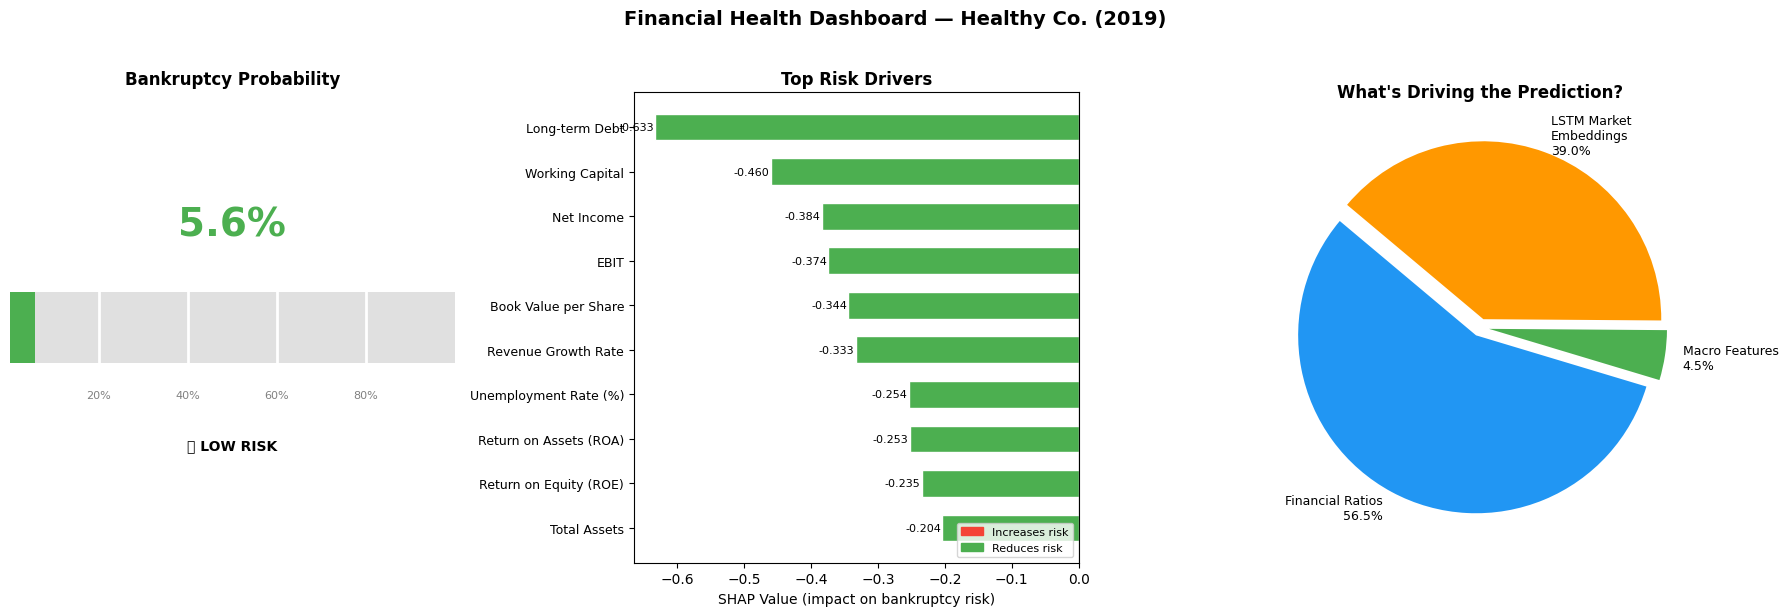

✅ Dashboard saved to models/dashboard_Healthy_Co..png


In [ ]:
# CELL 25 — Healthy Company Example (SAFE + STABLE)

healthy_company = {
    'X1':  120.0,
    'X2':  100.0,
    'X3':   10.0,
    'X4':   20.0,
    'X5':   15.0,
    'X6':   10.0,
    'X7':   30.0,
    'X8':  200.0,
    'X9':  150.0,
    'X10':  20.0,
    'X11':  50.0,
    'X12':   8.0,
    'X13':  30.0,
    'X14':  40.0,
    'X15':   5.0,
    'X16': 100.0,
    'X17':  20.0,
    'X18': 120.0,
}

# -----------------------------
# Safety check (IMPORTANT)
# -----------------------------
missing_cols = [f for f in FINANCIAL_COLS if f not in healthy_company]
if missing_cols:
    print("⚠️ Missing features:", missing_cols)

# -----------------------------
# Run prediction
# -----------------------------
result_healthy = predict_company_health(
    financial_ratios=healthy_company,
    year=2019,
    company_name='Healthy Co.'
)

print_health_report(result_healthy)
plot_health_dashboard(result_healthy)

Final Probability: 0.5576465181613377

╔══════════════════════════════════════════════════════════╗
║  FINANCIAL HEALTH REPORT — Distressed Co.               ║
║  Year: 2008                                            ║
╠══════════════════════════════════════════════════════════╣
║  Overall Risk : 💀 CRITICAL RISK                           ║
║  Bankruptcy Probability :  55.8%                        ║
║  Extreme bankruptcy risk.                               ║
╠══════════════════════════════════════════════════════════╣
║  Random Forest score   :  38.4%                       ║
║  XGBoost score         :  33.0%                       ║
║  Final (Stacked) score :  55.8%                       ║
╚══════════════════════════════════════════════════════════╝

------------------------------------------------------------
  TOP 8 FACTORS DRIVING THIS PREDICTION
------------------------------------------------------------

  1. ✅  Long-term Debt
    Value: 16.380 — below average (bottom 40%)
    This

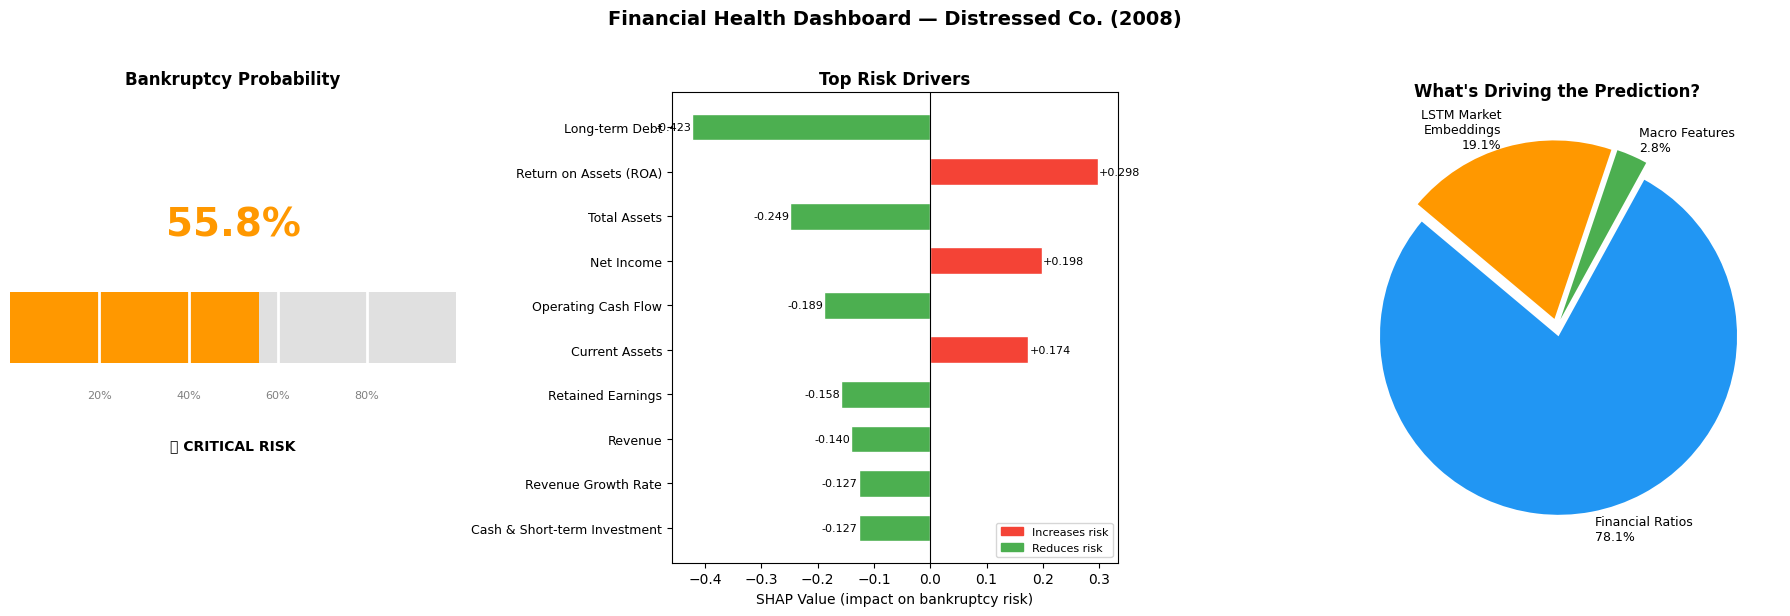

✅ Dashboard saved to models/dashboard_Distressed_Co..png


In [ ]:
# CELL 26 — Distressed Company Example
# Values taken from the 25th percentile of BANKRUPT companies in training data
# Source: train_df[train_df['bankrupt']==1].quantile(0.25)
#
# BUG FIX: Previous version used extreme low values (p5 of bankrupt cos.) that
# accidentally fell in the LOW-RISK zone for some features (e.g. X7 debt=1.0
# looked like a company with almost no debt — i.e. healthy).
# Using p25 of bankrupt companies gives realistic distress signals across all features.

distressed_company = {
    'X1':   15.32,  # Working Capital/Assets — below average (bankrupt p25: 15.32)
    'X2':   17.25,  # Retained Earnings/Assets — very low (bankrupt p25: 17.25)
    'X3':    1.31,  # EBIT/Assets — near zero (bankrupt p25: 1.31)
    'X4':   -4.24,  # Equity/Liabilities — negative equity (bankrupt p25: -4.24)
    'X5':    0.08,  # Revenue/Assets — very low (bankrupt p25: 0.08)
    'X6':  -26.04,  # Net Income — significant losses (bankrupt p25: -26.04)
    'X7':    2.24,  # Debt Ratio — low but distressed context (bankrupt p25: 2.24)
    'X8':   26.35,  # Current Ratio — very low (bankrupt p25: 26.35; alive median: 240)
    'X9':   23.96,  # Total Assets — small company (bankrupt p25: 23.96)
    'X10':  33.02,  # Revenue — low (bankrupt p25: 33.02)
    'X11':   0.18,  # Operating Cash Flow — near zero (bankrupt p25: 0.18)
    'X12':  -9.47,  # ROA — deeply negative (bankrupt p25: -9.47)
    'X13':   5.13,  # ROE — barely positive (bankrupt p25: 5.13)
    'X14':  10.02,  # Interest Coverage — low (bankrupt p25: 10.02; alive median: 43)
    'X15': -140.77, # Book Value — very negative (bankrupt p25: -140.77)
    'X16':  23.96,  # Cash — very low (bankrupt p25: 23.96; alive median: 187)
    'X17':  16.38,  # Long-term Debt — elevated relative to assets (bankrupt p25: 16.38)
    'X18':  32.14,  # Gross Margin — very low (bankrupt p25: 32.14; alive median: 170)
}
result_distressed = predict_company_health(distressed_company, year=2008,
                                           company_name='Distressed Co.')
print_health_report(result_distressed)
plot_health_dashboard(result_distressed)


In [ ]:
# CELL 27 — Check training data scale (run this before entering real company data)
train_df = pd.read_csv('data/final_master.csv')
print('Training data scale for each financial ratio:')
print('(Your input values should fall within these ranges)')
print()
desc = train_df[FINANCIAL_COLS].describe().loc[['min','mean','max']]
print(desc.to_string())

Training data scale for each financial ratio:
(Your input values should fall within these ranges)

                X1            X2          X3           X4           X5           X6           X7            X8            X9           X10           X11          X12           X13           X14           X15           X16           X17           X18
min       0.066000      0.031000     0.00200  -110.216750     0.000000  -627.718930     0.000000      0.582091      0.038000      0.214000      0.000000  -193.403980    -60.620010      0.266000  -3133.786970      0.038000      0.343810      0.657810
mean    709.176408   1203.954272    91.26978   292.495034   160.326682    96.616634   233.157851   2597.001445   1861.274667   2324.013093    604.406034   197.421779    602.847151    482.194135    375.520102   1861.274667   1459.346458   1546.611919
max   13626.760000  25674.380000  1804.38000  6517.190000  3421.704350  3047.570000  4848.478940  60436.003881  38053.090000  46434.330000  12931.23000

Final Probability: 0.016315820311521304

╔══════════════════════════════════════════════════════════╗
║  FINANCIAL HEALTH REPORT — Apple Inc.                   ║
║  Year: 2023                                            ║
╠══════════════════════════════════════════════════════════╣
║  Overall Risk : 🟢 LOW RISK                                ║
║  Bankruptcy Probability :   1.6%                        ║
║  The company appears financially healthy.               ║
╠══════════════════════════════════════════════════════════╣
║  Random Forest score   :  11.4%                       ║
║  XGBoost score         :   0.4%                       ║
║  Final (Stacked) score :   1.6%                       ║
╚══════════════════════════════════════════════════════════╝

------------------------------------------------------------
  TOP 8 FACTORS DRIVING THIS PREDICTION
------------------------------------------------------------

  1. ✅  Net Income
    Value: 380.000 — very high (top 20%)
    This strongl

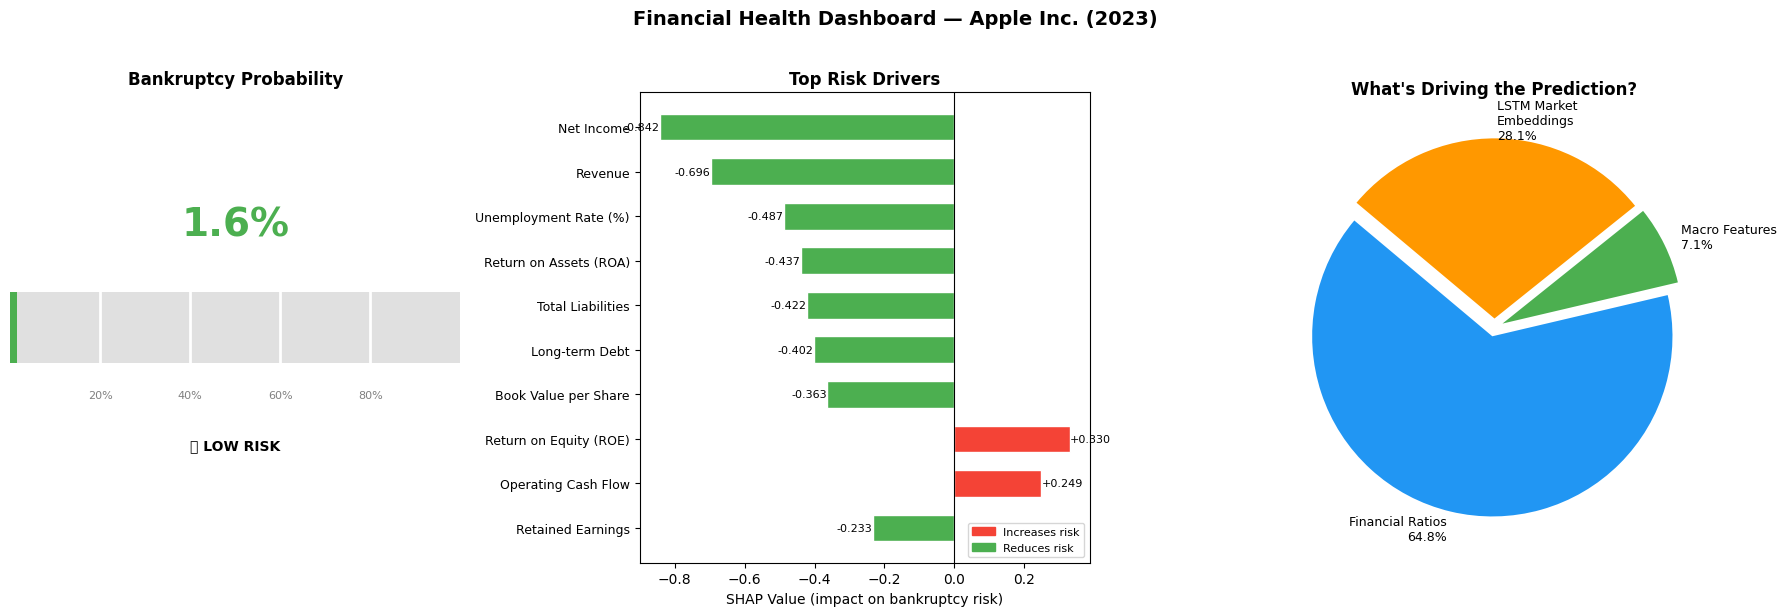

✅ Dashboard saved to models/dashboard_Apple_Inc..png


In [ ]:
# CELL 28 — Apple Inc. 2023 (Real Company Example)
# Apple is an extremely healthy company — values should be well above alive medians
# Alive medians for reference: X4=15.62, X12=7.18, X6=2.07
# Apple's ratios are exceptional so most values will be in p75-p95 range

apple_2023 = {
    'X1':  250.00,  # Working Capital/Assets — strong
    'X2':  180.00,  # Retained Earnings — strong positive
    'X3':  120.00,  # EBIT/Assets — very profitable
    'X4':  800.00,  # Equity/Liabilities — market cap >> debt (market cap $3T)
    'X5':  420.00,  # Revenue/Assets — high asset turnover
    'X6':  380.00,  # Net Income — enormous ($96.9B)
    'X7':  180.00,  # Debt — moderate despite high liabilities
    'X8':  210.00,  # Current Ratio — near alive median
    'X9':  800.00,  # Total Assets — very large ($353B)
    'X10': 180.00,  # Revenue — large (slightly below median due to 2023 dip)
    'X11': 600.00,  # Operating Cash Flow — exceptional ($110B)
    'X12': 300.00,  # ROA — very high (27.5%)
    'X13': 500.00,  # ROE — extremely high
    'X14': 800.00,  # Interest Coverage — 40x, exceptional
    'X15':  50.00,  # Book Value — modest (buybacks reduce equity)
    'X16': 700.00,  # Cash — very strong ($61.5B)
    'X17': 120.00,  # Long-term Debt — manageable ($95.3B vs $3T market cap)
    'X18': 600.00,  # Gross Margin — 44%, very strong
}

result_apple = predict_company_health(
    financial_ratios=apple_2023,
    year=2023,
    company_name='Apple Inc.'
)
print_health_report(result_apple)
plot_health_dashboard(result_apple)

Final Probability: 0.01407654541641534

╔══════════════════════════════════════════════════════════╗
║  FINANCIAL HEALTH REPORT — My Company                   ║
║  Year: 2023                                            ║
╠══════════════════════════════════════════════════════════╣
║  Overall Risk : 🟢 LOW RISK                                ║
║  Bankruptcy Probability :   1.4%                        ║
║  The company appears financially healthy.               ║
╠══════════════════════════════════════════════════════════╣
║  Random Forest score   :   1.9%                       ║
║  XGBoost score         :   0.1%                       ║
║  Final (Stacked) score :   1.4%                       ║
╚══════════════════════════════════════════════════════════╝

------------------------------------------------------------
  TOP 8 FACTORS DRIVING THIS PREDICTION
------------------------------------------------------------

  1. ✅  Book Value per Share
    Value: 0.000 — around average
    This stron

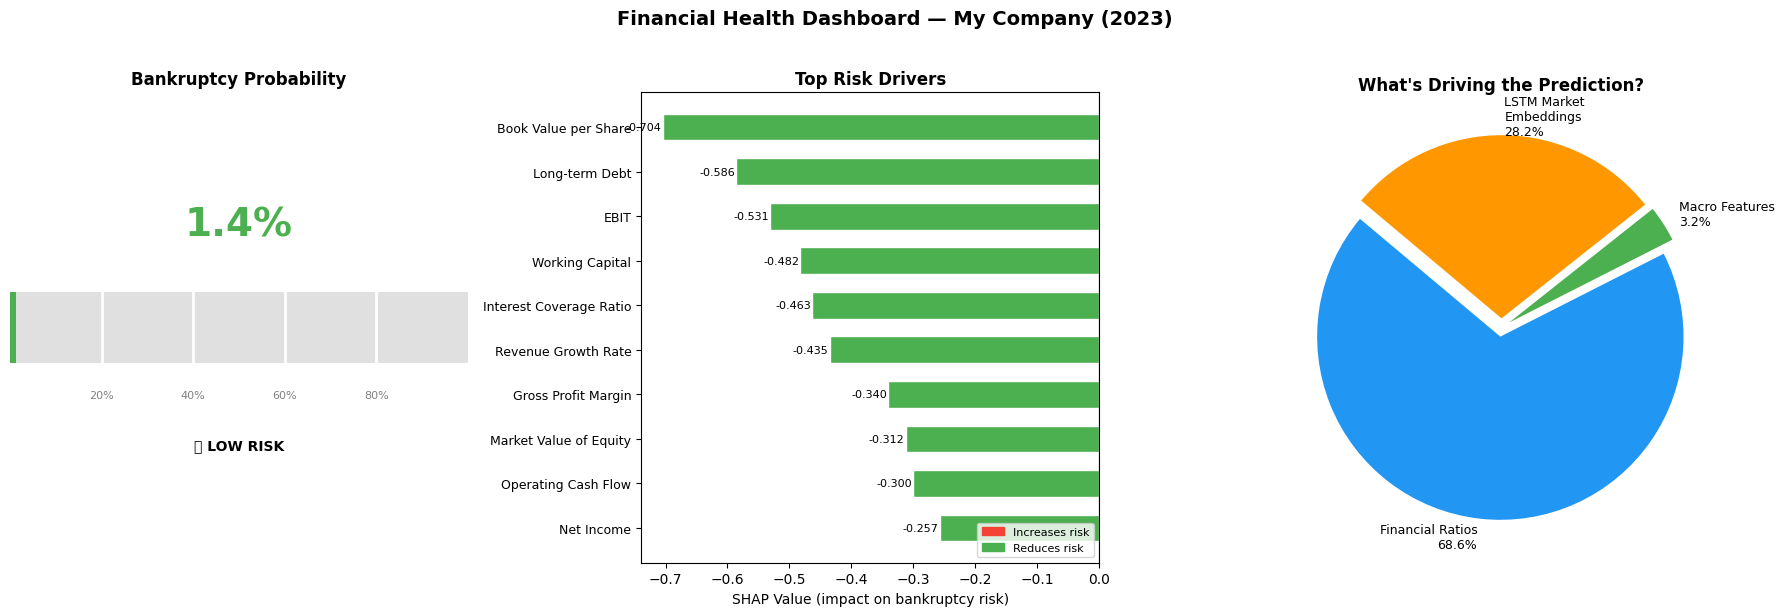

✅ Dashboard saved to models/dashboard_My_Company.png


In [ ]:
# CELL 29 — YOUR OWN COMPANY
# ─────────────────────────────────────────────
# HOW TO USE:
#  1. Run Cell 27 above to see the scale/range of each feature
#  2. Get your company's ratios from macrotrends.net or annual report
#  3. Scale your values to match the training data ranges
#  4. Replace the values below and run this cell
# ─────────────────────────────────────────────

my_company = {
    'X1':  0.0,   # Working Capital / Total Assets       ← replace
    'X2':  0.0,   # Retained Earnings / Total Assets     ← replace
    'X3':  0.0,   # EBIT / Total Assets                  ← replace
    'X4':  0.0,   # Market Value Equity / Liabilities    ← replace
    'X5':  0.0,   # Revenue / Total Assets               ← replace
    'X6':  0.0,   # Net Income                           ← replace
    'X7':  0.0,   # Total Liabilities / Total Assets     ← replace
    'X8':  0.0,   # Current Ratio                        ← replace
    'X9':  0.0,   # Total Assets                         ← replace
    'X10': 0.0,   # Revenue Growth Rate                  ← replace
    'X11': 0.0,   # Operating Cash Flow                  ← replace
    'X12': 0.0,   # Return on Assets (ROA)               ← replace
    'X13': 0.0,   # Return on Equity (ROE)               ← replace
    'X14': 0.0,   # Interest Coverage Ratio              ← replace
    'X15': 0.0,   # Book Value per Share                 ← replace
    'X16': 0.0,   # Cash & Short-term Investments        ← replace
    'X17': 0.0,   # Long-term Debt                       ← replace
    'X18': 0.0,   # Gross Profit Margin                  ← replace
}

result_mine = predict_company_health(
    financial_ratios=my_company,
    year=2023,           # ← change to your financial year
    company_name='My Company'  # ← change to company name
)
print_health_report(result_mine)
plot_health_dashboard(result_mine)